‎ 

> Source : [K Nearest Neighbors - Intuitive Machine Learning](https://www.youtube.com/watch?v=0p0o5cmgLdE)

‎ 


# 0. Setup

In [82]:
from Requirements import *

In [83]:
from tensorflow.keras.datasets import mnist

In [84]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [85]:
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

print("\nData type of images:", x_train.dtype)
print("Data type of labels:", y_train.dtype)

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)

Data type of images: uint8
Data type of labels: uint8


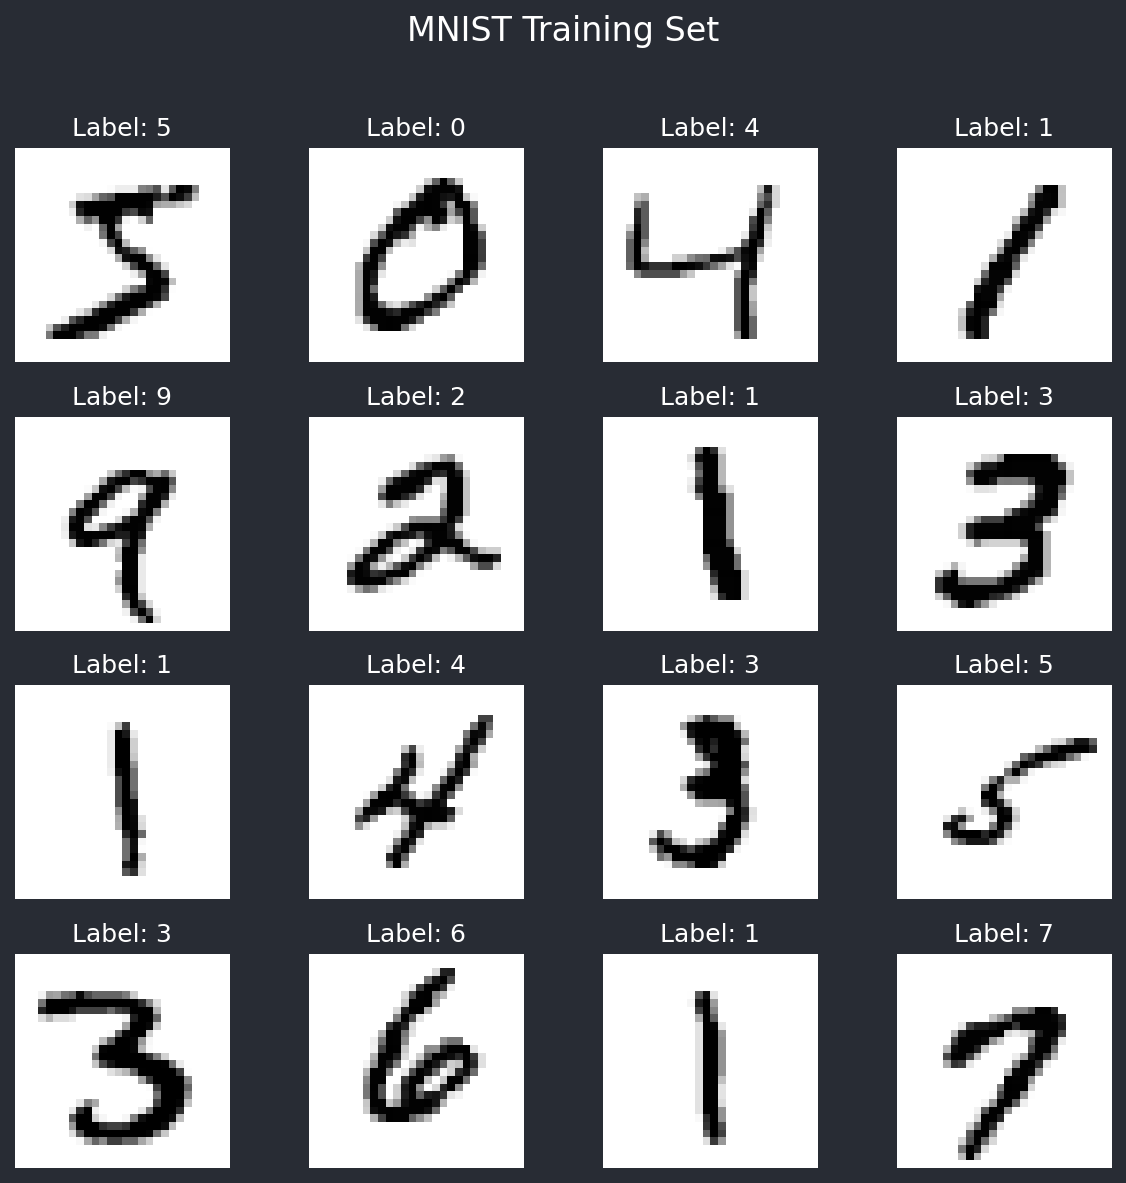

In [86]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(x_train[i], cmap='gray_r')
    
    ax.set_title(f"Label: {y_train[i]}")
    
    ax.axis('off')

plt.suptitle("MNIST Training Set", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

‎ 


# 1. Feature Vector Extraction 

The purpose of this section is to compare two different methods of extracting feature vectors from a test subject. For this project the MNIST dataset will be used, and the methods to be compared are: 

1. PCA - Principal Component Analysis

2. Texture and Statistic measurement

‎ 

## 1.1 PCA - Principal Component Analysis

PCA is a process to reduce the dimensionality of a dataset, while retaining as much variance as possible. It does this by identifying the directions (principal components) in which the data varies the most, and projecting the data onto these directions.

Let's assume we have a dataset represented by a matrix $X$ of size $n$ x $d$, where $n$ is the number of samples and $d$ is the number of features

‎ 

> 1. Standardize the Data

The first step in PCA is to standardize the data, which involves centering the data around the mean and scaling it to have unit variance. This is done so that each feature has a zero mean and unit variance. This prevents features with larger scales from dominating the analysis. For each feature column $j$ in $X$

$$
X_j' = \frac{X_j - \mu_j}{\sigma_j}
$$

where $X_j'$ is the standardized feature, $\mu_j$ is the mean of feature $j$, and $\sigma_j$ is the standard deviation of feature $j$. Let's call this new standardized data matrix $Z$.

‎ 

> 2. Compute the Covariance Matrix

The next step is to compute the covariance matrix of the standardized data. The covariance matrix captures the relationships between different features in the dataset. The covariance matrix $Σ$ is calculated as follows:

$$
\Sigma = \frac{1}{n-1} Z^T Z
$$

The terms $Z^T$ and $Z$ represent the transpose of the standardized data matrix and the standardized data matrix itself, respectively. The resulting covariance matrix $Σ$ will be of size $d$ x $d$, where each element $Σ_{ij}$ represents the covariance between features $i$ and $j$. The diagonal elements $Σ_{ii}$ represent the variance of each feature.

‎

> 3. Eigendecomposition of the Covariance Matrix

The next step is to perform eigendecomposition on the covariance matrix to find its eigenvalues and eigenvectors. The eigenvalues represent the amount of variance explained by each principal component, while the eigenvectors represent the directions of the principal components. This can be done using a linear algebra library or function that computes the eigenvalues and eigenvectors of a matrix.

$$
\Sigma v = \lambda v
$$

$v$ is an eigenvector of the covariance matrix $Σ$,  It's a $d$-dimensional vector. Eigenvectors represent the directions of the new axes in our feature space. Because the covariance matrix is symmetric, these eigenvectors will be orthogonal. These are the **principal components**.

$\lambda$ is the corresponding eigenvalue, which is a scalar. Eigenvalues indicate the amount of variance captured by each principal component. A higher eigenvalue means that the corresponding eigenvector captures more variance in the data.

‎

> 4. Sort Eigenvalues and Eigenvectors

We will get $d$ eigenvectors and $d$ corresponding eigenvalues. We sort the eigenvectors in descending order according to their eigenvalues.

The eigenvector with the largest eigenvalue is the first principal component (PC1). It is the direction that captures the most variance in the data. The eigenvector with the second-largest eigenvalue is the second principal component (PC2), which is orthogonal to PC1 and captures the most remaining variance, and so on. 


‎

> 5. Select Top $k$ Principal Components

To reduce the dimensionality of the dataset, we select the top $k$ eigenvectors (principal components) corresponding to the $k$ largest eigenvalues. The choice of $k$ depends on how much variance we want to retain in the reduced dataset. For this, we use the explained variance ratio, which is the ratio of each eigenvalue to the sum of all eigenvalues. 

$$
\text{Explained Variance Ratio} = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}
$$

We choose $k$ such that the explained variance ratio is above a certain threshold (e.g., 95%).

‎

> 6. Transform the Data

Finally, we project the standardized data $Z$, onto the selected $k$ principal components to obtain the reduced dataset. We create a matrix $W$ of size $d$ x $k$, where each column is one of the selected eigenvectors. 

$$
W = [v_1, v_2, ..., v_k]
$$

The new transformed dataset $Y$ is obtained by multiplying the standardized data matrix $Z$ with the projection matrix $W$:

$$
Y = Z W
$$

The resulting matrix $Y$ will be of size $n$ x $k$, where each row represents a sample in the reduced $k$-dimensional space. This reduced dataset can now be used for further analysis or machine learning tasks.

‎

____



‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

Before applying PCA, we need to prepare the data. For this, we need to flatten the images from 28x28 to 784-dimensional vectors and standardize the data.

</div>

‎ 

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [88]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)

x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("Shape of flattened x_train:", x_train_flat.shape)
print("Shape of flattened x_test:", x_test_flat.shape)


Shape of flattened x_train: (60000, 784)
Shape of flattened x_test: (10000, 784)


In [89]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_flat.astype(np.float64))
x_test_scaled = scaler.transform(x_test_flat.astype(np.float64))

# funding mean and std to verify standardization

print("Mean of scaled x_train :", np.mean(x_train_scaled, axis=0)[:].mean())
print("Std of scaled x_train :", np.std(x_train_scaled, axis=0)[:].mean())


Mean of scaled x_train : -4.908441927692891e-17
Std of scaled x_train : 0.9145408163265177


In [90]:
pca = PCA(n_components=0.95)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Shape of PCA-transformed x_train:", x_train_pca.shape)
print("Shape of PCA-transformed x_test:", x_test_pca.shape)

Shape of PCA-transformed x_train: (60000, 331)
Shape of PCA-transformed x_test: (10000, 331)



‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

To capture 95% of the information (variance) contained in the original 784 pixels, we only need 331 principal components. We've reduced the dimensionality of our data by over 50% while ensuring minimal information loss.

</div>

‎ 

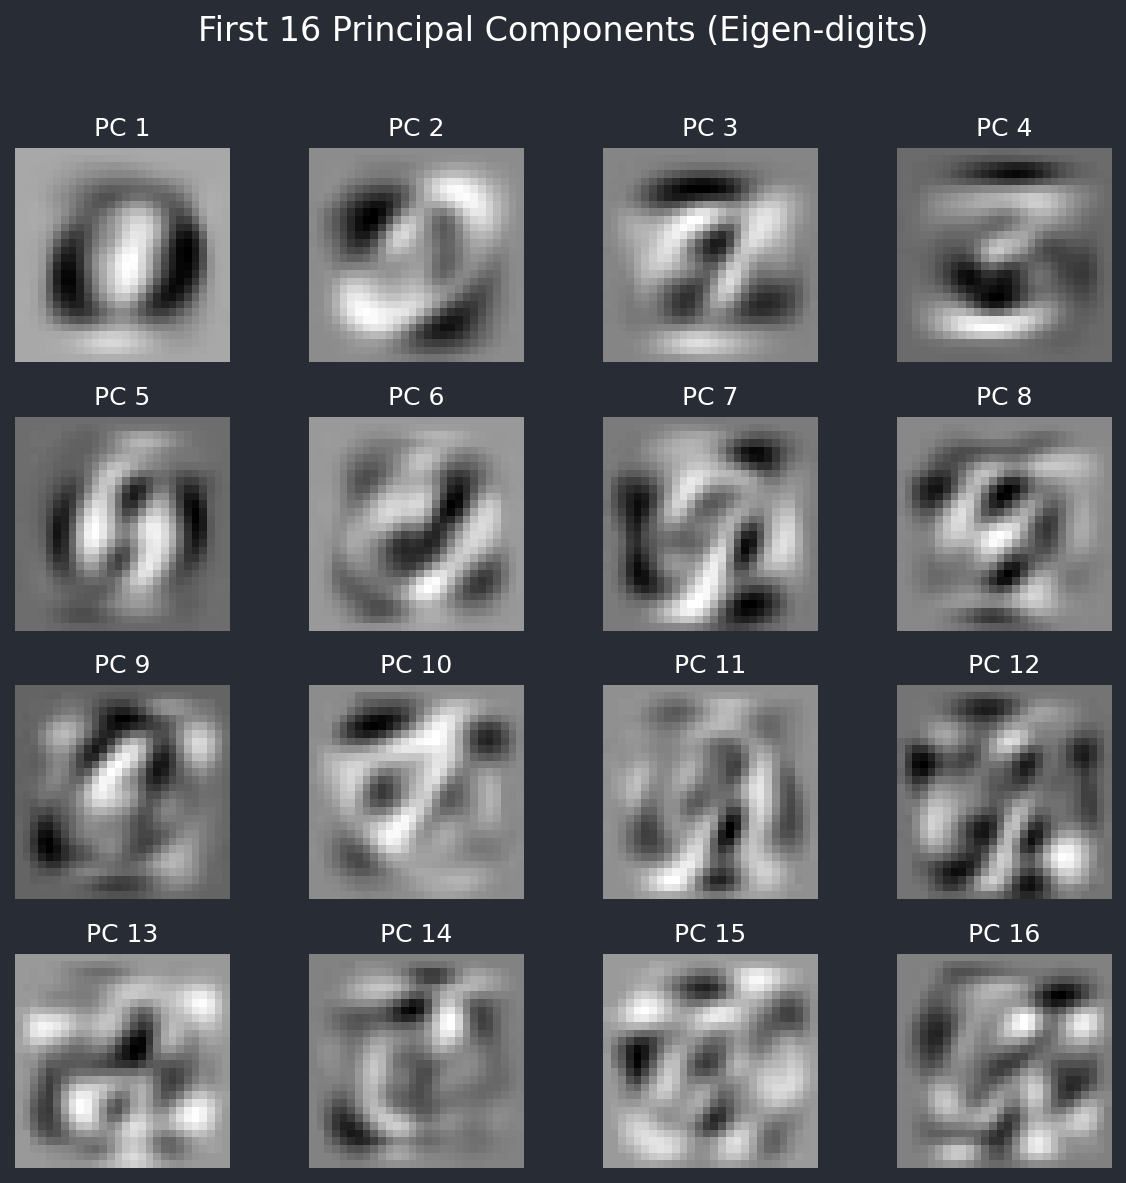

In [91]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(pca.components_[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')
    
plt.suptitle("First 16 Principal Components (Eigen-digits)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

Now we will implement the KNN algorithm using the PCA-reduced data. We will use the `KNeighborsClassifier` from the `sklearn` library to classify the digits based on their principal components.

</div>

‎ 

In [92]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [93]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_pca, y_train)

y_pred = knn.predict(x_test_pca)

In [94]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the KNN classifier: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy of the KNN classifier: 0.9486

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.96      0.99      0.98      1135
           2       0.96      0.94      0.95      1032
           3       0.94      0.96      0.95      1010
           4       0.95      0.94      0.95       982
           5       0.94      0.93      0.93       892
           6       0.96      0.97      0.97       958
           7       0.94      0.93      0.93      1028
           8       0.96      0.91      0.93       974
           9       0.93      0.92      0.92      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

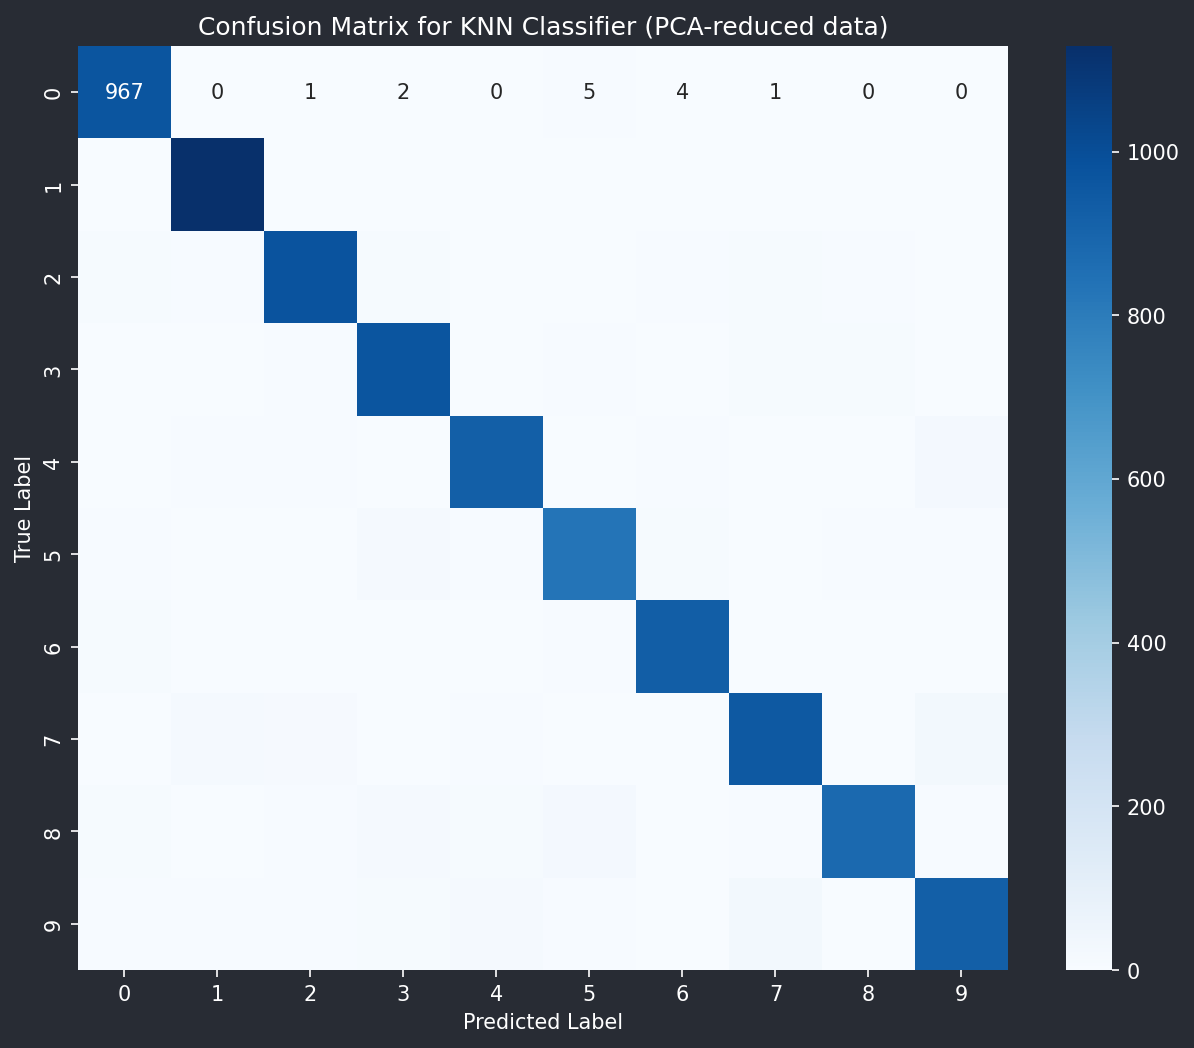

In [96]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix for KNN Classifier (PCA-reduced data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

To further reduce the dimensionality of the feature vector, we can choose two methods to reduce the PCA components: 

1. Method 1: Crop the Vector

    This method simply truncates the feature vector to a fixed size.

‎ 

2. Method 2: Select a Lower Variance

    This method uses the variance threshold to select the number of components that capture a lower percentage of variance, thus reducing the dimensionality further.

</div>

‎ 

In [97]:
k = 5
step_size = 5
max_components = x_train_pca.shape[1]

component_counts = range(10, max_components + 1, step_size)
accuracies = []

In [98]:
total_start_time = time.time()

for n_components in component_counts:
    
    start_time = time.time()
    
    x_train_subset = x_train_pca[:, :n_components]
    x_test_subset = x_test_pca[:, :n_components]
    
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    
    knn.fit(x_train_subset, y_train)
    
    y_pred_subset = knn.predict(x_test_subset)
    
    acc = accuracy_score(y_test, y_pred_subset)
    
    end_time = time.time()
    
    accuracies.append({"n_components": n_components, "accuracy": acc, "time_taken": end_time - start_time})
    
total_end_time = time.time()

print(f"\nTotal time taken: {total_end_time - total_start_time:.2f} seconds")


Total time taken: 59.15 seconds


In [99]:
df_accuracies = pd.DataFrame.from_records(accuracies)

df_accuracies.head()

,n_components,accuracy,time_taken
0,10,0.9075,0.698439
1,15,0.9378,1.223558
2,20,0.9460,0.380605
3,25,0.9493,0.396253
4,30,0.9523,0.406519


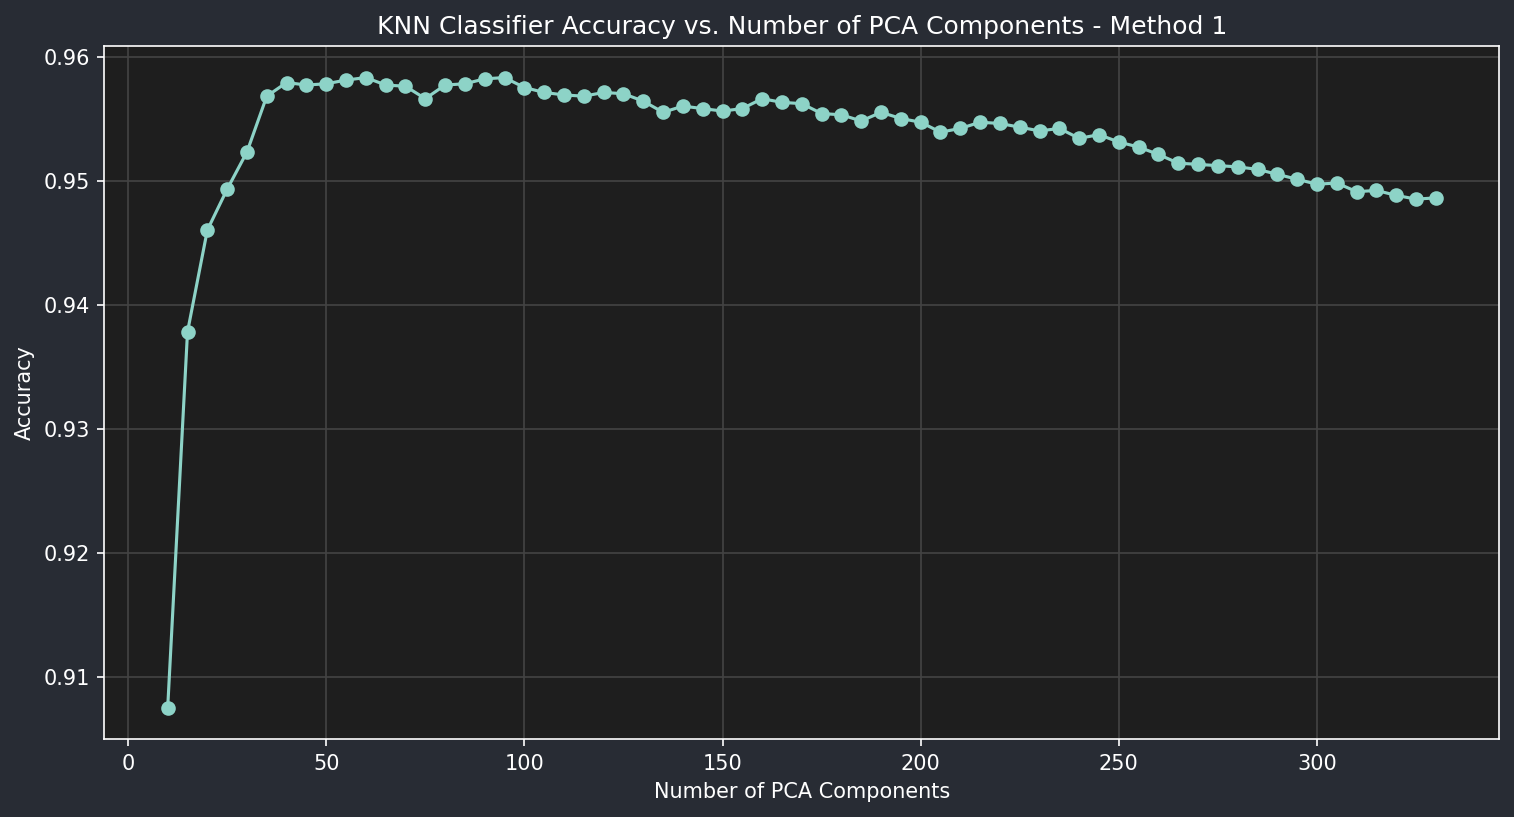

In [100]:
plt.figure(figsize=(12, 6))
plt.plot(df_accuracies['n_components'], df_accuracies['accuracy'], marker='o')
plt.title('KNN Classifier Accuracy vs. Number of PCA Components - Method 1')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [101]:
best_result = max(accuracies, key=lambda x: x['accuracy'])

print(f"Best accuracy of {best_result['accuracy']:.4f} achieved with {best_result['n_components']} PCA components.")

Best accuracy of 0.9583 achieved with 60 PCA components.



‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

The Method 1 (cropping the vector) using a variance of 95% gives us the best accuracy of 95.83% with 60 PCA components. This counterintuitive result is a direct result of **curse of dimensionality**, where having too many features can lead to overfitting and reduced model performance.

</div>

‎ 

In [102]:
k = 5
step_size = 0.05

variance_thresholds = np.arange(0.10, 1.0, step_size)

accuracies_m2 = []

In [103]:
total_start_time = time.time()

for variance in variance_thresholds:
    
    start_time = time.time()
    
    pca = PCA(n_components = variance)
    
    x_train_pca_var = pca.fit_transform(x_train_scaled)
    x_test_pca_var = pca.transform(x_test_scaled)
    
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    
    knn.fit(x_train_pca_var, y_train)
    
    y_pred_var = knn.predict(x_test_pca_var)
    
    acc = accuracy_score(y_test, y_pred_var)
    
    end_time = time.time()
    
    accuracies_m2.append({"variance_threshold": variance, "n_components": pca.n_components_, "accuracy": acc, "time_taken": end_time - start_time})
    
    pass
    
total_end_time = time.time()

print(f"\nTotal time taken: {total_end_time - total_start_time:.2f} seconds")


Total time taken: 41.22 seconds


In [104]:
df_accuracies_m2 = pd.DataFrame.from_records(accuracies_m2)

df_accuracies_m2.head()

,variance_threshold,n_components,accuracy,time_taken
0,0.10,3,0.5194,2.302957
1,0.15,4,0.6680,2.199898
2,0.20,6,0.8348,2.159213
3,0.25,9,0.8893,2.336142
4,0.30,12,0.9202,2.372239


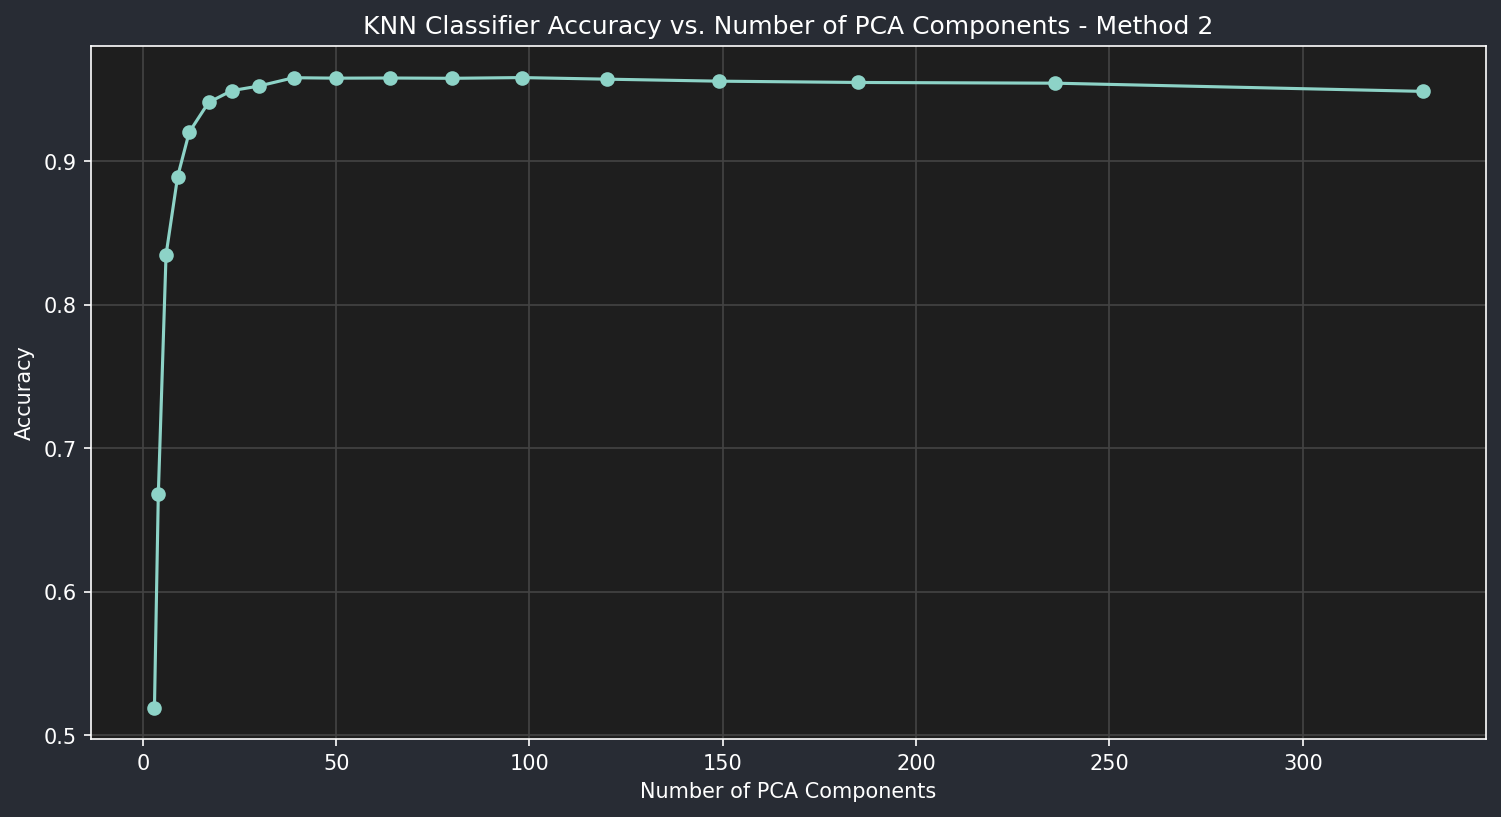

In [105]:
plt.figure(figsize=(12, 6))
plt.plot(df_accuracies_m2['n_components'], df_accuracies_m2['accuracy'], marker='o')
plt.title('KNN Classifier Accuracy vs. Number of PCA Components - Method 2')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [106]:
best_result_m2 = max(accuracies_m2, key=lambda x: x['accuracy'])

print(f"Best accuracy of {best_result_m2['accuracy']:.4f} achieved with {best_result_m2['n_components']} PCA components (Variance Threshold: {best_result_m2['variance_threshold']:.2f}).")

Best accuracy of 0.9582 achieved with 98 PCA components (Variance Threshold: 0.70).



‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

The Method 2 (Altering variance) gives us the best accuracy of 95.82% with 98 PCA components, using a variance threshold of 70%. 

This indicates a clear difference in performance between the two methods of dimensionality reduction, while the first method obtained an accuracy of 95.83% with 60 PCA components, the **second method achieved a comparable accuracy with a higher number of components**. 

</div>

‎ 

In [107]:
#df_accuracies.to_csv("1. Data/1. DataFrame/knn_accuracies_method1.csv", index=False)

#df_accuracies_m2.to_csv("1. Data/1. DataFrame/knn_accuracies_method2.csv", index=False)

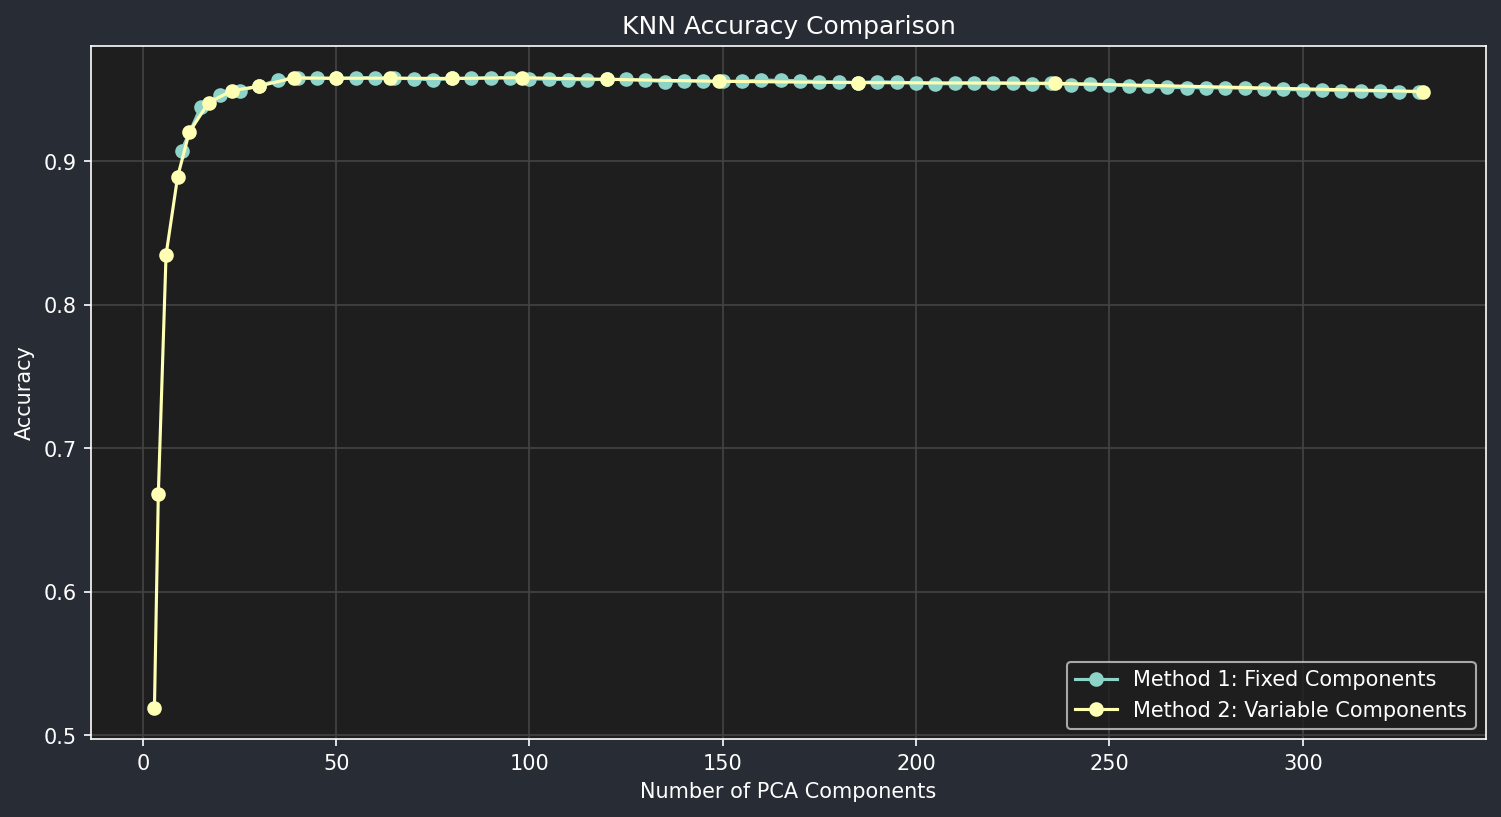

In [108]:
# Comparing both methods in a single graph

plt.figure(figsize=(12, 6))
plt.plot(df_accuracies['n_components'], df_accuracies['accuracy'], marker='o', label='Method 1: Fixed Components')
plt.plot(df_accuracies_m2['n_components'], df_accuracies_m2['accuracy'], marker='o', label='Method 2: Variable Components')
plt.title('KNN Accuracy Comparison')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

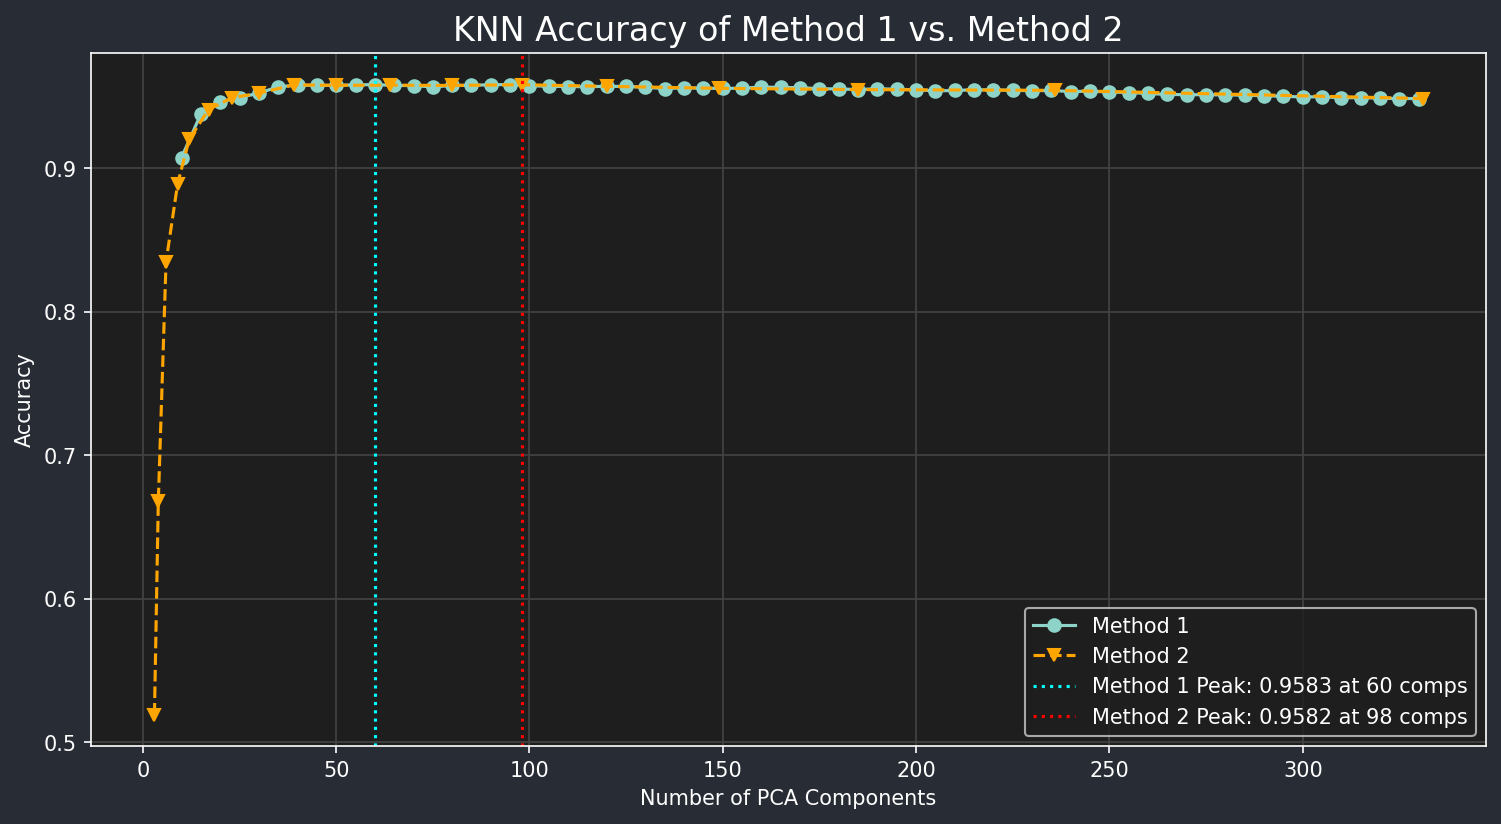

In [109]:
plt.figure(figsize=(12, 6))

plt.plot(df_accuracies['n_components'], df_accuracies['accuracy'], marker='o', linestyle='-', label='Method 1')

plt.plot(df_accuracies_m2['n_components'], df_accuracies_m2['accuracy'], marker='v', linestyle='--', color='orange', label='Method 2')

peak1 = df_accuracies.loc[df_accuracies['accuracy'].idxmax()]
plt.axvline(x=peak1['n_components'], color='cyan', linestyle=':', label=f"Method 1 Peak: {peak1['accuracy']:.4f} at {int(peak1['n_components'])} comps")

peak2 = df_accuracies_m2.loc[df_accuracies_m2['accuracy'].idxmax()]
plt.axvline(x=peak2['n_components'], color='red', linestyle=':', label=f"Method 2 Peak: {peak2['accuracy']:.4f} at {int(peak2['n_components'])} comps")

plt.title('KNN Accuracy of Method 1 vs. Method 2', fontsize=16)
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

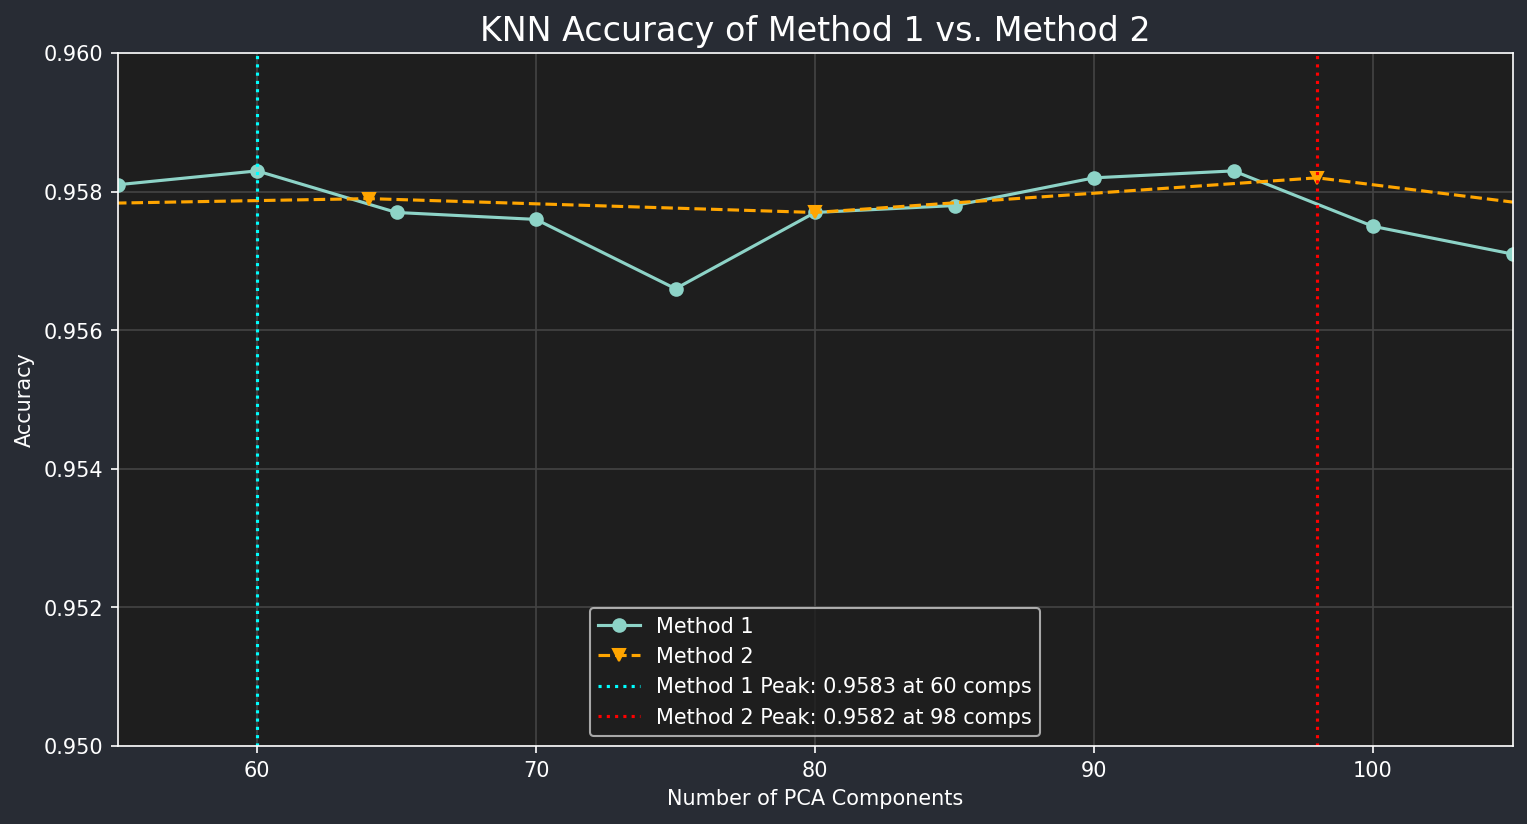

In [110]:
# zoom in important graph area

plt.figure(figsize=(12, 6))
#plt.xlim(5, 110)
plt.xlim(55, 105)
plt.ylim(0.95, 0.96)

plt.plot(df_accuracies['n_components'], df_accuracies['accuracy'], marker='o', linestyle='-', label='Method 1')

plt.plot(df_accuracies_m2['n_components'], df_accuracies_m2['accuracy'], marker='v', linestyle='--', color='orange', label='Method 2')

peak1 = df_accuracies.loc[df_accuracies['accuracy'].idxmax()]
plt.axvline(x=peak1['n_components'], color='cyan', linestyle=':', label=f"Method 1 Peak: {peak1['accuracy']:.4f} at {int(peak1['n_components'])} comps")

peak2 = df_accuracies_m2.loc[df_accuracies_m2['accuracy'].idxmax()]
plt.axvline(x=peak2['n_components'], color='red', linestyle=':', label=f"Method 2 Peak: {peak2['accuracy']:.4f} at {int(peak2['n_components'])} comps")

plt.title('KNN Accuracy of Method 1 vs. Method 2', fontsize=16)
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

To more accurately compare the two methods, we will run the KNN algorithm with a random subset of the test data, multiple times for each method and collect the accuracy results for the best accuracy and record the PCA components used.
Then, we will use a side-by-side Box Plot to visualize the distribution of accuracies for both methods.

</div>

‎ 

In [111]:
number_of_runs = 40
subset_size = 5000
k = 5

step_size_m1 = 5
step_size_m2 = 0.05

peak_accuracies_m1, optimal_components_m1 = [], []
peak_accuracies_m2, optimal_components_m2 = [], []

In [112]:
if False: 

    total_start_time = time.time()

    for i in tqdm(range(number_of_runs)):
        
        run_start_time = time.time()
        
        random_indices = np.random.choice(x_test_scaled.shape[0], subset_size, replace=False)
        
        y_test_subset = y_test[random_indices]
        
        # Method 1
        
        pca_m1 = PCA(n_components = 0.95)
        
        x_train_pca_m1 = pca_m1.fit_transform(x_train_scaled)
        
        x_test_pca_m1 = pca_m1.transform(x_test_scaled[random_indices])
        
        run_accuracies_m1 = []
        
        for n_components in range(10, x_test_pca_m1.shape[1] + 1, step_size_m1):
            
            knn_m1 = KNeighborsClassifier(n_neighbors = k, n_jobs = -1)
            
            knn_m1.fit(x_train_pca_m1[:, :n_components], y_train)
            
            y_pred_m1 = knn_m1.predict(x_test_pca_m1[:, :n_components])
            
            acc_m1 = accuracy_score(y_test_subset, y_pred_m1)
            
            run_accuracies_m1.append((acc_m1, n_components))
            
            pass
        
        peak_acc_m1, best_n_comp_m1 = max(run_accuracies_m1, key=lambda x: x[0])
        
        peak_accuracies_m1.append(peak_acc_m1)
        optimal_components_m1.append(best_n_comp_m1)
        
        # Method 2
        
        run_accuracies_m2 = []
        
        variance_values = np.arange(0.50, 1.0, step_size_m2)
        
        for variance in variance_values:
            
            pca_m2 = PCA(n_components = variance)
            
            x_train_pca_m2 = pca_m2.fit_transform(x_train_scaled)
            
            x_test_pca_m2 = pca_m2.transform(x_test_scaled[random_indices])
            
            knn_m2 = KNeighborsClassifier(n_neighbors = k, n_jobs = -1)
            
            knn_m2.fit(x_train_pca_m2, y_train)
            
            y_pred_m2 = knn_m2.predict(x_test_pca_m2)
            
            acc_m2 = accuracy_score(y_test_subset, y_pred_m2)
            
            run_accuracies_m2.append((acc_m2, pca_m2.n_components_))
            
            pass
        
        peak_acc_m2, best_n_comp_m2 = max(run_accuracies_m2, key=lambda x: x[0])
        
        peak_accuracies_m2.append(peak_acc_m2)
        optimal_components_m2.append(best_n_comp_m2)
        
        run_end_time = time.time()
        
        pass

    total_end_time = time.time()

    print(f"\nTotal time taken : {total_end_time - total_start_time:.2f} seconds")

In [113]:
if False:
    
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_peak_accuracies_m1.pkl", "wb") as f:
        
        pickle.dump(peak_accuracies_m1, f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_optimal_components_m1.pkl", "wb") as f:
        
        pickle.dump(optimal_components_m1, f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_peak_accuracies_m2.pkl", "wb") as f:
        
        pickle.dump(peak_accuracies_m2, f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_optimal_components_m2.pkl", "wb") as f:
        
        pickle.dump(optimal_components_m2, f)
        

if True:

    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_peak_accuracies_m1.pkl", "rb") as f:
        
        peak_accuracies_m1 = pickle.load(f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_optimal_components_m1.pkl", "rb") as f:
        
        optimal_components_m1 = pickle.load(f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_peak_accuracies_m2.pkl", "rb") as f:
        
        peak_accuracies_m2 = pickle.load(f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/knn_optimal_components_m2.pkl", "rb") as f:
        
        optimal_components_m2 = pickle.load(f)

In [114]:
print(f"{peak_accuracies_m1}\n{optimal_components_m1}")
print(f"{peak_accuracies_m2}\n{optimal_components_m2}")

[0.9558, 0.9596, 0.961, 0.9606, 0.9578, 0.9564, 0.9586, 0.9598, 0.9596, 0.9584, 0.9576, 0.9614, 0.9618, 0.9588, 0.9588, 0.9594, 0.9592, 0.9588, 0.9586, 0.9622, 0.9572, 0.9578, 0.9604, 0.9594, 0.9614, 0.959, 0.9556, 0.9588, 0.9598, 0.9598, 0.9572, 0.9588, 0.9612, 0.9606, 0.959, 0.96, 0.9582, 0.9582, 0.9624, 0.9584]
[40, 60, 90, 60, 60, 90, 80, 55, 60, 40, 60, 85, 90, 40, 60, 40, 90, 70, 60, 80, 60, 95, 90, 40, 90, 35, 95, 95, 35, 80, 60, 55, 95, 40, 55, 40, 85, 35, 60, 55]
[0.9556, 0.9586, 0.9606, 0.9604, 0.9572, 0.9564, 0.9586, 0.9598, 0.9594, 0.9588, 0.9574, 0.9606, 0.9608, 0.9592, 0.9586, 0.9596, 0.9588, 0.9586, 0.9584, 0.9622, 0.9568, 0.958, 0.9598, 0.9596, 0.961, 0.9582, 0.9556, 0.9592, 0.9592, 0.9598, 0.9568, 0.9584, 0.9604, 0.9606, 0.959, 0.96, 0.9582, 0.958, 0.9614, 0.9578]
[39, 80, 98, 39, 39, 98, 80, 98, 64, 39, 39, 39, 98, 39, 50, 39, 39, 80, 80, 80, 39, 98, 98, 98, 98, 39, 98, 98, 39, 80, 39, 50, 64, 39, 64, 39, 39, 39, 64, 39]


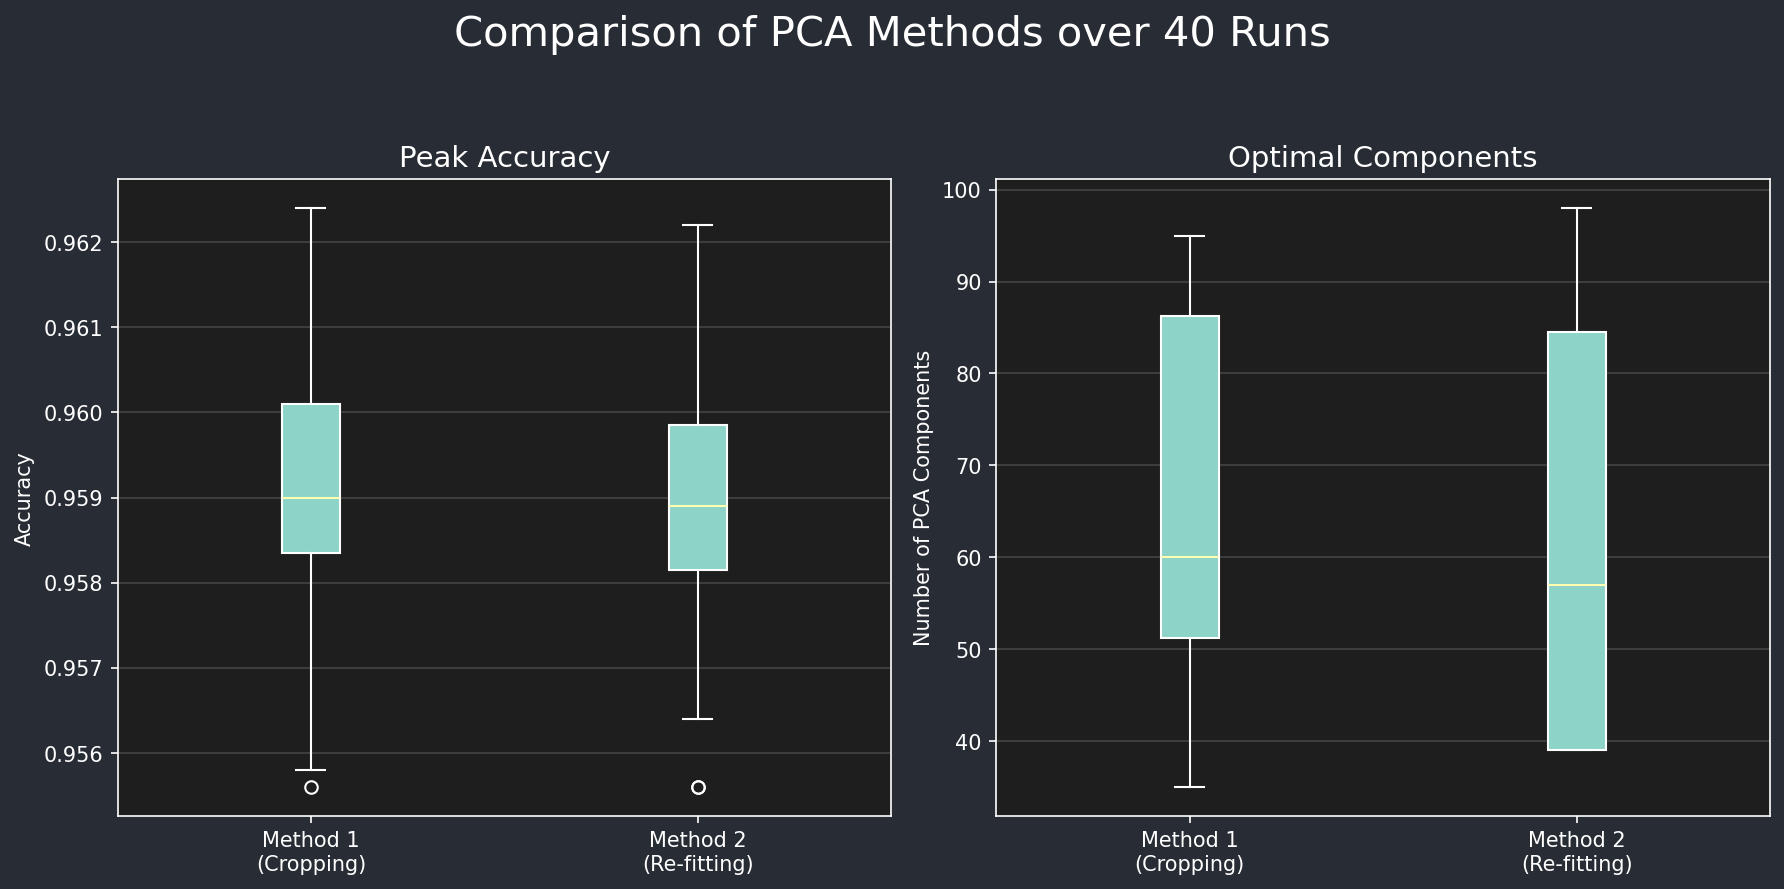

In [115]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)

box_data_acc = [peak_accuracies_m1, peak_accuracies_m2]
labels_acc = [f'Method 1\n(Cropping)', f'Method 2\n(Re-fitting)']

plt.boxplot(box_data_acc, patch_artist=True, labels=labels_acc)
plt.title(f'Peak Accuracy', fontsize=14)
plt.ylabel('Accuracy')
plt.grid(True, axis='y')

plt.subplot(1, 2, 2)

box_data_comps = [optimal_components_m1, optimal_components_m2]
labels_comps = [f'Method 1\n(Cropping)', f'Method 2\n(Re-fitting)']

plt.boxplot(box_data_comps, patch_artist=True, labels=labels_comps)
plt.title(f'Optimal Components', fontsize=14)
plt.ylabel('Number of PCA Components')
plt.grid(True, axis='y')

plt.suptitle(f'Comparison of PCA Methods over {number_of_runs} Runs', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

The result obtained from the box plot can help us understand the variability and consistency of each method.

1. Peak Accuracy: 

    The horizontal lines inside the boxes (the medians) are at almost the exact same height. This means that, on average, both methods achieve the same level of peak accuracy.

    Both methods have a similar level of consistency in their performance across different data subsets, demonstrated by the comparable heights of the boxes and whiskers. 

    Thus, **there is no statistically significant difference in the accuracy of Method 1 and Method 2.**

2. Optimal PCA Components: 

    The median from method 2 is lower than that of method 1, indicating that method 2 generally requires fewer PCA components to achieve its peak accuracy, but it also shows a wider range of PCA components used across different runs.

‎ 

> In conclusion, while both methods achieve similar peak accuracies, Method 2 tends to use fewer PCA components on average, and because of that it could be considered more efficient in terms of dimensionality reduction.


</div>

‎ 

‎ 

## 1.2 Texture and Statistic Measurement

These features are derived from the pixel intensity values of the images and provide information about the texture and statistical properties of the patterns in the images.

‎ 

### 1.2.1 Global Statistical Features

‎ 

1. **Mean** : The average pixel intensity value of the image, which gives an indication of the overall brightness of the image.

    $$
    \mu = \frac{1}{N} \sum_{i=1}^{N} p_i
    $$

    Where $N$ is the total number of pixels in the image, and $p_i$ is the intensity value of the $i^{th}$ pixel.

‎ 

2. **Standard Deviation** : A measure of the spread of pixel intensity values around the mean, which indicates the contrast in the image. Its the square root of the variance.

    $$
    \sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (p_i - \mu)^2}
    $$

‎ 

3. **Entropy** : A measure of the randomness or complexity of the pixel intensity distribution in the image. It quantifies the amount of information contained in the image.

    $$
    H = - \sum_{i=0}^{L-1} P(i) \log_2(P(i))
    $$

    Where $L$ is the number of possible intensity levels (e.g., 256 for 8-bit images), and $P(i)$ is the probability of intensity level $i$ occurring in the image. By convention, $0 \log_2(0)$ is defined to be 0.



In [116]:
from skimage import exposure
from skimage.measure import shannon_entropy
from skimage.feature import graycomatrix, graycoprops

In [117]:
def calculate_global_features(image):

    mean_intensity = np.mean(image)
    
    std_intensity = np.std(image)

    entropy = shannon_entropy(image)

    return [mean_intensity, std_intensity, entropy]

In [118]:
sample_image = x_train[0]

global_features_sample = calculate_global_features(sample_image)

print(f"Global Features of sample image - {y_train[0]}:\n")
print(f"Mean Intensity: {global_features_sample[0]:.4f}")
print(f"Std Deviation: {global_features_sample[1]:.4f}")
print(f"Entropy: {global_features_sample[2]:.4f}")

Global Features of sample image - 5:

Mean Intensity: 35.1084
Std Deviation: 79.6488
Entropy: 1.8285


In [119]:
x_train_global_features = np.array([calculate_global_features(img) for img in x_train])

print("Shape of global features array:", x_train_global_features.shape)

Shape of global features array: (60000, 3)


‎ 

### 1.2.2 GLCM Features

The Gray Level Co-occurrence Matrix (GLCM) is a statistical method used to analyze the texture of an image by examining the spatial relationships between pixel intensity values. The GLCM is a matrix that represents how often pairs of pixel with specific values and in a specified spatial relationship occur in an image.

The GLCM matrix is created with a specified distance and angle. Commonly used angles are 0°, 45°, 90°, and 135°. The distance is typically set to 1 pixel, but it can be adjusted based on the texture scale of interest.

The GLCM $P(i, j, d, \theta)$ is a $L$ x $L$ matrix, where $L$ is the number of gray levels in the image, and each element $P(i, j, d, \theta)$ represents the frequency of occurrence of a pixel with intensity $i$ being adjacent to a pixel with intensity $j$ at a distance $d$ and angle $\theta$.

After counting pairs of pixel intensities, this matrix is normalized by dividing every cell by the total number of pairs counted. This turns the counts into probabilities, $p(i, j) = \frac{P(i, j)}{\sum_{i=0}^{L-1} \sum_{j=0}^{L-1} P(i, j)}$.

We can extract several statistical features from the GLCM to quantify the texture of the image. Some commonly used GLCM features include:

‎ 

1. **Contrast** : Measures the local variations in the GLCM. It is high when the image has a lot of local variations (i.e., high contrast) and low when the image is more uniform.

    $$
    \text{Contrast} = \sum_{i=0}^{L-1} \sum_{j=0}^{L-1} (i - j)^2 p(i, j)
    $$

‎ 

2. **Correlation** : Measures the linear dependency of gray levels on those of neighboring pixels. It indicates how correlated a pixel is to its neighbor over the entire image.

    $$
    \text{Correlation} = \frac{\sum_{i=0}^{L-1} \sum_{j=0}^{L-1} (i - \mu_i)(j - \mu_j) p(i, j)}{\sigma_i \sigma_j}
    $$

    Where $\mu_i$ and $\mu_j$ are the means of the row and column sums of the GLCM, and $\sigma_i$ and $\sigma_j$ are the standard deviations of the row and column sums.

‎ 

3. **Energy** (Angular Second Moment) : Measures the uniformity of the GLCM. It is high when the image has a lot of repeated pairs of pixel values (i.e., high uniformity) and low when the image has a more complex texture.

    $$
    \text{Energy} = \sum_{i=0}^{L-1} \sum_{j=0}^{L-1} p(i, j)^2
    $$ 

‎ 

4. **Homogeneity** (Inverse Difference Moment) : Measures the closeness of the distribution of elements in the GLCM to the GLCM diagonal. It is high when the image has a lot of similar pixel values (i.e., high homogeneity) and low when the image has a more complex texture.

    $$
    \text{Homogeneity} = \sum_{i=0}^{L-1} \sum_{j=0}^{L-1} \frac{p(i, j)}{1 + |i - j|}
    $$

‎ 

In [120]:
image = x_train[0]

image_scaled = (image / image.max() * 255).astype(np.uint8)

glcm = graycomatrix(image_scaled, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)

print("GLCM shape:", glcm.shape)

GLCM shape: (256, 256, 1, 4)


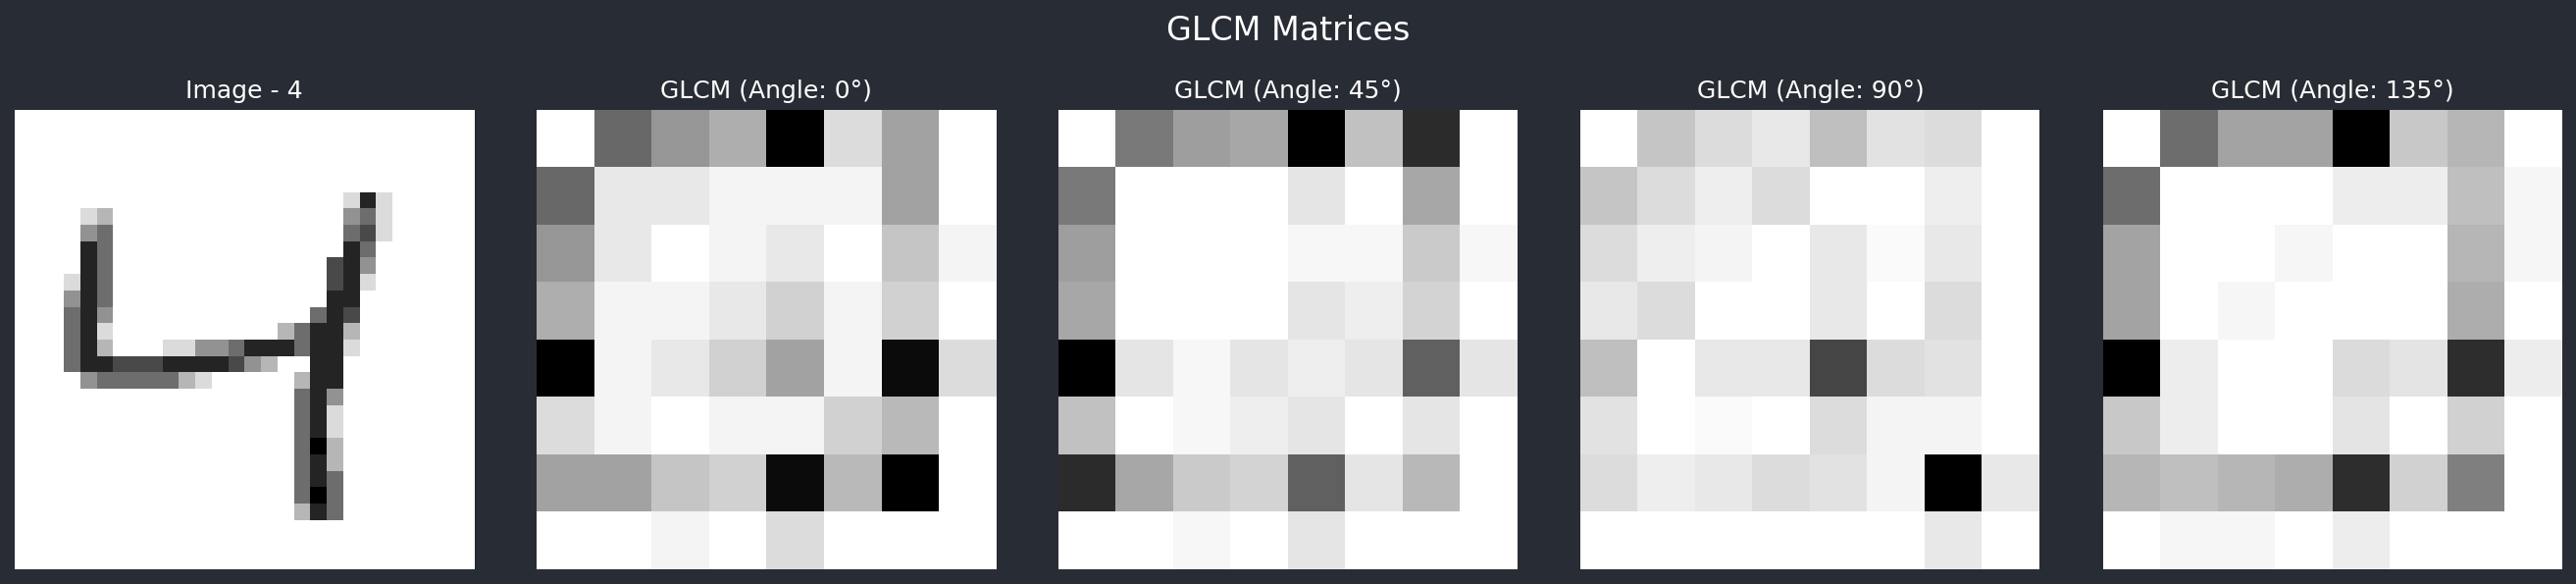

In [121]:
image = x_train[(index := 2)]

image_scaled = (image / image.max() * 255).astype(np.uint8)

image_quantized = exposure.rescale_intensity(image_scaled, out_range=(0, 7)).astype(np.uint8)

glcm_quantized = graycomatrix(image_quantized, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=8, symmetric=True, normed=True)


fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(image_quantized, cmap='gray_r', interpolation='nearest')
axes[0].set_title(f"Image - {y_train[index]}")
axes[0].axis('off')

for i, angle in enumerate([0, 45, 90, 135]):
    glcm_matrix = glcm_quantized[:, :, 0, i]

    glcm_matrix[0, 0] = 0
    
    log_glcm = np.log1p(glcm_matrix)
    
    im = axes[i+1].imshow(log_glcm, cmap='gray_r', interpolation='nearest')
    axes[i+1].set_title(f"GLCM (Angle: {angle}°)")
    axes[i+1].axis('off')

plt.suptitle("GLCM Matrices", fontsize=16)
plt.subplots_adjust(top=0.25)
plt.tight_layout()
plt.show()


‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

The first thing to decide is the amount of GLCM matrices to compute per image. Each GLCM matrix is computed for a specific distance and angle.

Also, there are a few ways to construct the feature vector from the GLCM features. Here we will explore 3 possibilities :

1. Averaging Method : Compute the GLCM features for each matrix and then average the results across all matrices to get a single set of features.

> [avg_contrast, avg_correlation, avg_energy, avg_homogeneity]

2. Concatenation Method : Compute the GLCM features for each matrix and then concatenate the results to form a longer feature vector.

> [contrast_1, correlation_1, energy_1, homogeneity_1, ..., contrast_n, correlation_n, energy_n, homogeneity_n]

3.  Statistical Summary Method : Compute the GLCM features for each matrix and then compute statistical summaries (mean, std) for each feature across all matrices.

> [mean_contrast, mean_correlation, mean_energy, mean_homogeneity, std_contrast, std_correlation, std_energy, std_homogeneity]


Specifically, for the testing we will use 4 GLCM matrices per image, with a distance of 1 and angles of 0°, 45°, 90°, and 135°.


</div>

‎ 

In [122]:
x_train_global_features = np.array([calculate_global_features(img) for img in x_train])

x_test_global_features = np.array([calculate_global_features(img) for img in x_test])

print("Shape of train featur array:", x_train_global_features.shape)
print("Shape of test featur array:", x_test_global_features.shape)

Shape of train featur array: (60000, 3)
Shape of test featur array: (10000, 3)


In [134]:
train_glcm_features = []
test_glcm_features = []

In [ ]:
if False:    
    
    for image in tqdm(x_train):
        
        image_scaled = (image / 32).astype(np.uint8)
        
        glcm = graycomatrix(image_scaled, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=8, symmetric=True, normed=True)
        
        contrast = graycoprops(glcm, prop='contrast')
        correlation = graycoprops(glcm, prop='correlation')
        energy = graycoprops(glcm, prop='energy')
        homogeneity = graycoprops(glcm, prop='homogeneity')
        
        train_glcm_features.append(np.array([contrast.ravel(), correlation.ravel(), energy.ravel(), homogeneity.ravel()]))

    train_glcm_features = np.array(train_glcm_features)

    for image in tqdm(x_test):
        
        image_scaled = (image / 32).astype(np.uint8)

        glcm = graycomatrix(image_scaled, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=8, symmetric=True, normed=True)

        contrast = graycoprops(glcm, prop='contrast')
        correlation = graycoprops(glcm, prop='correlation')
        energy = graycoprops(glcm, prop='energy')
        homogeneity = graycoprops(glcm, prop='homogeneity')

        test_glcm_features.append(np.array([contrast.ravel(), correlation.ravel(), energy.ravel(), homogeneity.ravel()]))
        
    test_glcm_features = np.array(test_glcm_features)

In [ ]:
if False:

    with open("1. Data/4. Pickles/1. Quantum Machine Learning/x_train_global_features.pkl", "wb") as f:
        pickle.dump(x_train_global_features, f)

    with open("1. Data/4. Pickles/1. Quantum Machine Learning/x_test_global_features.pkl", "wb") as f:
        pickle.dump(x_test_global_features, f)

    with open("1. Data/4. Pickles/1. Quantum Machine Learning/train_glcm_features.pkl", "wb") as f:
        pickle.dump(train_glcm_features, f)

    with open("1. Data/4. Pickles/1. Quantum Machine Learning/test_glcm_features.pkl", "wb") as f:
        pickle.dump(test_glcm_features, f)


if True:

    with open("1. Data/4. Pickles/1. Quantum Machine Learning/x_train_global_features.pkl", "rb") as f:
        x_train_global_features = pickle.load(f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/x_test_global_features.pkl", "rb") as f:
        x_test_global_features = pickle.load(f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/train_glcm_features.pkl", "rb") as f:
        train_glcm_features = pickle.load(f)
        
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/test_glcm_features.pkl", "rb") as f:
        test_glcm_features = pickle.load(f)

In [137]:
# Method 1

x_train_GLCM_m1 = np.mean(train_glcm_features, axis=2)

x_test_GLCM_m1 = np.mean(test_glcm_features, axis=2)

x_train_combined_m1 = np.concatenate((x_train_global_features, x_train_GLCM_m1), axis=1)

x_test_combined_m1 = np.concatenate((x_test_global_features, x_test_GLCM_m1), axis=1)

# Method 2

x_train_GLCM_m2 = train_glcm_features.reshape(train_glcm_features.shape[0], -1)

x_test_GLCM_m2 = test_glcm_features.reshape(test_glcm_features.shape[0], -1)

x_train_combined_m2 = np.concatenate((x_train_global_features, x_train_GLCM_m2), axis=1)

x_test_combined_m2 = np.concatenate((x_test_global_features, x_test_GLCM_m2), axis=1)

# Method 3

x_train_GLCM_m3 = np.concatenate((np.mean(train_glcm_features, axis=2), np.std(train_glcm_features, axis=2)), axis=1)

x_test_GLCM_m3 = np.concatenate((np.mean(test_glcm_features, axis=2), np.std(test_glcm_features, axis=2)), axis=1)

x_train_combined_m3 = np.concatenate((x_train_global_features, x_train_GLCM_m3), axis=1)

x_test_combined_m3 = np.concatenate((x_test_global_features, x_test_GLCM_m3), axis=1)


In [138]:
headers = ["Method", "Train Shape", "Test Shape"]

table = [["Method 1: Mean GLCM", x_train_combined_m1.shape, x_test_combined_m1.shape], ["Method 2: Full GLCM", x_train_combined_m2.shape, x_test_combined_m2.shape], ["Method 3: Mean + Std GLCM", x_train_combined_m3.shape, x_test_combined_m3.shape]]

print(tabulate(table, headers))

Method                     Train Shape    Test Shape
-------------------------  -------------  ------------
Method 1: Mean GLCM        (60000, 7)     (10000, 7)
Method 2: Full GLCM        (60000, 19)    (10000, 19)
Method 3: Mean + Std GLCM  (60000, 11)    (10000, 11)


In [139]:
dataset = {"Method 1: Mean GLCM": (x_train_combined_m1, x_test_combined_m1), "Method 2: Full GLCM": (x_train_combined_m2, x_test_combined_m2), "Method 3: Mean + Std GLCM": (x_train_combined_m3, x_test_combined_m3)}

results = []

k = 5

for item, (data_train, data_test) in dataset.items():
    
    scaler = StandardScaler()
    
    data_train_scaled = scaler.fit_transform(data_train)
    
    data_test_scaled = scaler.transform(data_test)
    
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    knn.fit(data_train_scaled, y_train)

    y_pred = knn.predict(data_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    
    dims = data_train.shape[1]

    results.append((item, dims, accuracy))  

print(tabulate(results, ["Method", "Dimensions", "Accuracy"]))

Method                       Dimensions    Accuracy
-------------------------  ------------  ----------
Method 1: Mean GLCM                   7      0.2965
Method 2: Full GLCM                  19      0.5366
Method 3: Mean + Std GLCM            11      0.3966



‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

From this results we can conclude that the best method for constructing the feature vector from the Method 2, where we concatenate the GLCM features from each matrix. This method was able to achieve an accuracy of 53.66% with a feature vector size of 19.

This result shows a sub-par performance compared to the PCA method, which achieved an accuracy of 51.94% with 3 PCA components, or with comparable dimensions, 17 we obtained an accuracy of 94.09%.

This result indicates that **while GLCM features can capture some texture information, they are not effective enough for the MNIST digit classification** task on their own, so we will not explore this method further and focus on PCA for the KNN implementation.


</div>

‎ 

‎ 

## 1.3 Impact of feature vector size on accuracy

In this section we will explore how the size of the feature vector impacts the accuracy of the KNN algorithm. We will use the PCA method for this exploration, as it has shown to be more effective than the GLCM method.
